### 다항 회귀
- 회귀선이 직선의 형태로 예측이 잘 되지 않는 부분을 2차, 3차 곡선을 이용하여 회귀선을 생성하는 부분
- 새로운 파생변수가 생성이 되는 과정
    - 0차원
        - y절편
    - 1차원
        - 원래 가지고 있던 변수들을 그대로 유지
    - 2차원
        - 자기복재(제곱) : 각 변수를 제곱한 값이 생성
        - 상호 작용(곱셈) : 서로 다른 변수끼리 곱한 항이 생성
        


In [1]:
import pandas as pd

In [2]:
cereal = pd.read_csv('../data/cereal.csv')

In [3]:
cereal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB


In [4]:
cereal.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.597403,6.922078,96.077922,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,4.278956,4.444885,71.286813,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,40.000000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.000000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


- 시리얼 데이터 컬럼의 의미
    - name
        - 시리얼 제품명
        - 분석의 독립변수로서는 의미가 없다.
    - mfr
        - 제조사의 알파벳 약자
        - 독립변수로 사용하려면 문자를 숫자로 변환(더미변수 변환 가능)
    - type
        - 섭취 유형(Cold/Hot)
        - 독립변수로 사용하려면 더미변수 (원 핫 인코딩)
    - calories
        - 1회 제공량 당 칼로리
    - protein
        - 단백질
    - fet
        - 지방
    - sodium
        - 나트륨
    - fiber
        - 식이섬유
    - carbo
        - 복합 탄수화물
    - sugars
        - 당분(설탕)
    - potass
        - 칼륨
    - vitamin
        - 비타민 및 미네랄 함유량
    - shelf
        - 마트 진열대 위치(층수)
    - weight
        - 1회 제공량의 무게
    - cups
        - 1회 제공량의 부피
    - rating
        - 소비자 리포트 종합 평전(target/종속변수)

In [5]:
#-1이 존재하는 데이터가 어떤 것인가?
flag=cereal['sugars']<0

cereal.loc[flag,]

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
57,Quaker Oatmeal,Q,H,100,5,2,0,2.7,-1.0,-1,110,0,1,1.0,0.67,50.828392


In [11]:
#carbo, sugars, potass 컬럼에서 0보다 작은 값들을 모두 확인
#조건식 3개를 생성하여 or로 연결
#컬럼을 3개 선택하여 0보다 작다 조건식을 이용하고 any() -> loc[]
flag2=(cereal[['carbo','sugars','potass']]<0).any(axis=1)

cereal.loc[flag2,]

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
20,Cream of Wheat (Quick),N,H,100,3,0,80,1.0,21.0,0,-1,0,2,1.0,1.00,64.533816
57,Quaker Oatmeal,Q,H,100,5,2,0,2.7,-1.0,-1,110,0,1,1.0,0.67,50.828392


In [9]:
#음수인 데이터를 제거
#case1 : drop()함수 사용
cereal.drop([4,20,57],axis=0)

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
5,Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1.0,0.75,29.509541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,Trix,G,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,Wheat Chex,R,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [13]:
#flag2를 부정(~ | -)해서 필터링
df=cereal.loc[~flag2,]

In [14]:
df.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,107.027027,2.513514,1.000000,162.364865,2.175676,14.729730,7.108108,98.513514,29.054054,2.216216,1.030811,0.821622,42.371787
std,19.843893,1.075802,1.006826,82.769787,2.423391,3.891675,4.359111,70.878681,22.294352,0.832067,0.153416,0.235715,14.033712
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,135.000000,0.250000,12.000000,3.000000,41.250000,25.000000,1.250000,1.000000,0.670000,32.449210
50%,110.000000,2.500000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.253086
75%,110.000000,3.000000,1.000000,217.500000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.520611
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

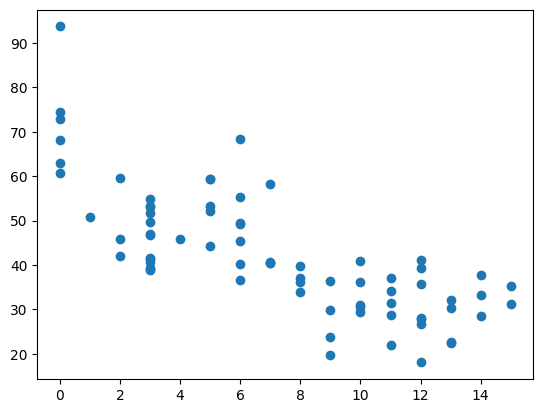

In [16]:
#scatter그래프를 이용하여 sugars, rating의 산점도 그래프 확인
plt.scatter(
    df['sugars'],
    df['rating'],
)

plt.show()

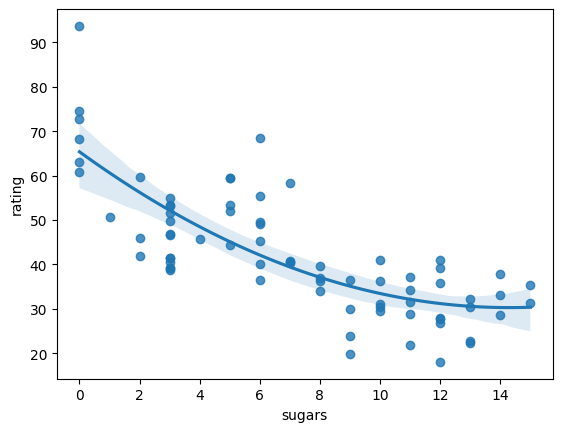

In [21]:
#산점도의 회귀선을 추가하여 그래프 확인(다항 회귀선)
sns.regplot(
    data=df,
    x='sugars',
    y='rating',
    order=2
)
plt.show()

In [23]:
#상관계수를 확인하려면 corr()
df.iloc[:,3:].corr().iloc[-1]

calories   -0.693785
protein     0.467162
fat        -0.405050
sodium     -0.383012
fiber       0.603411
carbo       0.055941
sugars     -0.755955
potass      0.415782
vitamins   -0.214481
shelf       0.051040
weight     -0.300461
cups       -0.222504
rating      1.000000
Name: rating, dtype: float64

In [25]:
#sugars 컬럼만 사용하여 단순선형회귀 방식을 이용하여 모댈 성능 평가
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [29]:
x=df[['sugars']] #컬럼을 단일로 선택하면 Series // 독립변수는 2차원 데이터
y=df['rating']

x_train,x_test,y_train,y_test=train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [30]:
lr=LinearRegression()
lr.fit(x_train,y_train)

pred_1=lr.predict(x_test)

mae_1=mean_absolute_error(y_test,pred_1)

print(round(mae_1,4))

7.4697


In [31]:
#다항 회귀를 이용하기 위해 컬럼을 출가 -> 제곱합 추가
#n차원 다항 조건을 생성하기 위한 기능 로드
from sklearn.preprocessing import PolynomialFeatures

In [32]:
#class 생성
#degree (기본값 : 2) -> n차원 사용하려면 변경
poly_reg=PolynomialFeatures()

#데이터를 fit하고 transform
x_train_poly=poly_reg.fit_transform(x_train)
x_test_poly=poly_reg.transform(x_test)

x_train_poly

array([[  1.,  13., 169.],
       [  1.,   0.,   0.],
       [  1.,   6.,  36.],
       [  1.,   8.,  64.],
       [  1.,  11., 121.],
       [  1.,   5.,  25.],
       [  1.,   7.,  49.],
       [  1.,  10., 100.],
       [  1.,   3.,   9.],
       [  1.,   3.,   9.],
       [  1.,  10., 100.],
       [  1.,  12., 144.],
       [  1.,  13., 169.],
       [  1.,   0.,   0.],
       [  1.,   0.,   0.],
       [  1.,  13., 169.],
       [  1.,   3.,   9.],
       [  1.,   5.,  25.],
       [  1.,   2.,   4.],
       [  1.,   8.,  64.],
       [  1.,   6.,  36.],
       [  1.,  14., 196.],
       [  1.,   6.,  36.],
       [  1.,   9.,  81.],
       [  1.,   3.,   9.],
       [  1.,   2.,   4.],
       [  1.,  12., 144.],
       [  1.,   3.,   9.],
       [  1.,  12., 144.],
       [  1.,   2.,   4.],
       [  1.,   7.,  49.],
       [  1.,   0.,   0.],
       [  1.,   3.,   9.],
       [  1.,   9.,  81.],
       [  1.,   4.,  16.],
       [  1.,   3.,   9.],
       [  1.,   3.,   9.],
 

In [35]:
#선형 모델 학습 및 예측
lr.fit(x_train_poly,y_train)

pred_2=lr.predict(x_test_poly)

mae_2=mean_absolute_error(y_test,pred_2)

print(round(mae_2,4))

6.2037


In [36]:
#칼로리, 당분 데이터를 독립 변수 다항 회귀에서 사용
x=df[['calories','sugars']]
y=df['rating']

x_train,x_test,y_train,y_test=train_test_split(
    x, y, test_size=0.3, random_state=42
)

x_train_poly=poly_reg.fit_transform(x_train)
x_test_poly=poly_reg.transform(x_test)

lr.fit(x_train_poly, y_train)

pred_3=lr.predict(x_test_poly)


mae_3=mean_absolute_error(y_test,pred_3)


print(round(mae_3,4))

7.3017


In [44]:
#df에서 문자열로 이루어진 데이터의 컬럼은 모두 제외하고
#선형회귀 방식으로 mae값과
#다중회귀(2차) 방식으로 mae값의 차이를 확인
#train : test = 7 : 3

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      74 non-null     object 
 1   mfr       74 non-null     object 
 2   type      74 non-null     object 
 3   calories  74 non-null     int64  
 4   protein   74 non-null     int64  
 5   fat       74 non-null     int64  
 6   sodium    74 non-null     int64  
 7   fiber     74 non-null     float64
 8   carbo     74 non-null     float64
 9   sugars    74 non-null     int64  
 10  potass    74 non-null     int64  
 11  vitamins  74 non-null     int64  
 12  shelf     74 non-null     int64  
 13  weight    74 non-null     float64
 14  cups      74 non-null     float64
 15  rating    74 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB


In [45]:
df.iloc[:,3:]

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
5,110,2,2,180,1.5,10.5,10,70,25,1,1.0,0.75,29.509541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [48]:
#특정 데이터 타입의 컬럼을 선택
#선택(select) + 데이터 타입들(dtypes) -> select_dtypes()
#각각의 타입들을 []로 묶어서 사용
# df.select_dtypes(['int','float'])

#숫자형 타입만 보고 싶다 -> number
df2=df.select_dtypes('number')

In [51]:
x=df2.drop('rating',axis=1)
y=df2['rating']

x_train,x_test,y_train,y_test=train_test_split(
    x, y, test_size=0.3, random_state=42
)

lr.fit(x_train, y_train)

pred_4=lr.predict(x_test)

mae_4=mean_absolute_error(y_test,pred_4)

print(round(mae_4,4))

0.0


In [53]:
x_train_poly=poly_reg.fit_transform(x_train)
x_test_poly=poly_reg.transform(x_test)

lr.fit(x_train_poly, y_train)

pred_5=lr.predict(x_test_poly)

mae_5=mean_absolute_error(y_test,pred_5)

print(round(mae_5,4))

1.5368


In [54]:
x_train_poly

array([[  1.    , 160.    ,   3.    , ...,   2.25  ,   1.005 ,   0.4489],
       [  1.    ,  90.    ,   3.    , ...,   1.    ,   0.67  ,   0.4489],
       [  1.    ,  90.    ,   2.    , ...,   1.    ,   0.67  ,   0.4489],
       ...,
       [  1.    , 100.    ,   3.    , ...,   1.    ,   0.67  ,   0.4489],
       [  1.    , 110.    ,   2.    , ...,   1.    ,   1.    ,   1.    ],
       [  1.    , 100.    ,   3.    , ...,   1.    ,   1.    ,   1.    ]],
      shape=(51, 91))

In [55]:
x_train

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups
46,160,3,2,150,3.0,17.0,13,160,25,3,1.50,0.67
64,90,3,0,0,4.0,19.0,0,140,0,1,1.00,0.67
8,90,2,1,200,4.0,15.0,6,125,25,1,1.00,0.67
59,100,3,2,140,2.5,10.5,8,140,25,3,1.00,0.50
44,150,4,3,95,3.0,16.0,11,170,25,3,1.00,1.00
32,100,3,1,140,3.0,15.0,5,85,25,3,1.00,0.88
49,140,3,2,220,3.0,21.0,7,130,25,3,1.33,0.67
51,130,3,2,170,1.5,13.5,10,120,25,3,1.25,0.50
21,110,2,0,220,1.0,21.0,3,30,25,3,1.00,1.00
62,110,2,0,290,0.0,22.0,3,35,25,1,1.00,1.00
